## 1. Setup and Configuration

In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm

# =============================================================================
# DIRECTORY PATHS
# =============================================================================
CODE_DIR = Path(r"c:\Users\skazempour\Dropbox\Projects\42 - Machine learning from the crowd\Code")
DATA_DIR = Path(r"c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\csv")

# Input: Cleaned StockTwits data by year
STOCKTWITS_FOLDER = DATA_DIR / "cleaned_by_year_mlcrowd"

# Intermediate: Exploded data (one row per symbol)
EXPLODED_FOLDER = DATA_DIR / "exploded_by_year_mlcrowd"
EXPLODED_FOLDER.mkdir(parents=True, exist_ok=True)

# CRSP data location
CRSP_FOLDER = Path(r"D:\CRSP")

# Output: Merged data
OUTPUT_FOLDER = DATA_DIR / "merged_with_crsp_mlcrowd"
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

# =============================================================================
# PARAMETERS
# =============================================================================
# Horizons for abnormal returns (matching feature_proposal.md: 5, 21, 63, 252 days)
# Also including 1, 3, 10, 42 for more granularity
HORIZONS = [1, 3, 5, 21, 63]

print(f"StockTwits folder: {STOCKTWITS_FOLDER}")
print(f"Exploded folder: {EXPLODED_FOLDER}")
print(f"CRSP folder: {CRSP_FOLDER}")
print(f"Output folder: {OUTPUT_FOLDER}")
print(f"Horizons: {HORIZONS}")

StockTwits folder: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\csv\cleaned_by_year_mlcrowd
Exploded folder: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\csv\exploded_by_year_mlcrowd
CRSP folder: D:\CRSP
Output folder: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\csv\merged_with_crsp_mlcrowd
Horizons: [1, 3, 5, 21, 63]


## 2. Inspect Available Data

In [2]:
# Check available StockTwits files
stocktwits_files = sorted([f for f in os.listdir(STOCKTWITS_FOLDER) if f.endswith('.csv')])
print(f"StockTwits files found: {len(stocktwits_files)}")
print(f"Files: {stocktwits_files}\n")

# Extract years from filenames
stocktwits_years = [int(f.split('_')[-1].replace('.csv', '')) for f in stocktwits_files]
print(f"Years in StockTwits data: {stocktwits_years}\n")

# Check available CRSP files
crsp_files = sorted([f for f in os.listdir(CRSP_FOLDER) if f.startswith('dsf_final_') and f.endswith('.pkl')])
print(f"CRSP files found: {len(crsp_files)}")
print(f"Files: {crsp_files}\n")

# Extract years from CRSP filenames
crsp_years = [int(f.split('_')[-1].replace('.pkl', '')) for f in crsp_files]
print(f"Years in CRSP data: {crsp_years}\n")

# Find overlapping years
overlap_years = sorted(set(stocktwits_years) & set(crsp_years))
print(f"Years available in both datasets: {overlap_years}")

StockTwits files found: 15
Files: ['stocktwits_cleaned_2010.csv', 'stocktwits_cleaned_2011.csv', 'stocktwits_cleaned_2012.csv', 'stocktwits_cleaned_2013.csv', 'stocktwits_cleaned_2014.csv', 'stocktwits_cleaned_2015.csv', 'stocktwits_cleaned_2016.csv', 'stocktwits_cleaned_2017.csv', 'stocktwits_cleaned_2018.csv', 'stocktwits_cleaned_2019.csv', 'stocktwits_cleaned_2020.csv', 'stocktwits_cleaned_2021.csv', 'stocktwits_cleaned_2022.csv', 'stocktwits_cleaned_2023.csv', 'stocktwits_cleaned_2024.csv']

Years in StockTwits data: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

CRSP files found: 17
Files: ['dsf_final_2008.pkl', 'dsf_final_2009.pkl', 'dsf_final_2010.pkl', 'dsf_final_2011.pkl', 'dsf_final_2012.pkl', 'dsf_final_2013.pkl', 'dsf_final_2014.pkl', 'dsf_final_2015.pkl', 'dsf_final_2016.pkl', 'dsf_final_2017.pkl', 'dsf_final_2018.pkl', 'dsf_final_2019.pkl', 'dsf_final_2020.pkl', 'dsf_final_2021.pkl', 'dsf_final_2022.pkl', 'dsf_final_2023.pkl', 

## 2a. Inspect Sample Data Structure (Before Explosion)

## 3. Explode Symbol List

Before merging with CRSP, we need to explode the `symbol_list` column so that each symbol gets its own row. If a message mentions multiple symbols, it will create one row per symbol with all other columns duplicated.


In [3]:
import ast

def explode_symbol_list(df):
    """
    Explode symbol_list column to create one row per symbol.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with 'symbol_list' column containing list of symbols
        
    Returns:
    --------
    pd.DataFrame: Exploded dataframe with 'symbol' column and duplicated other columns
    """
    df = df.copy()
    
    # Parse symbol_list if it's a string
    df['symbol_list_parsed'] = df['symbol_list'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )
    
    # Filter out rows with empty or invalid symbol lists
    df = df[df['symbol_list_parsed'].apply(
        lambda x: isinstance(x, list) and len(x) > 0
    )]
    
    # Explode the list - creates one row per symbol
    df_exploded = df.explode('symbol_list_parsed')
    
    # Rename the exploded column to 'symbol'
    df_exploded = df_exploded.rename(columns={'symbol_list_parsed': 'symbol'})
    
    # Drop the original symbol_list column
    df_exploded = df_exploded.drop(columns=['symbol_list'])
    
    # Reset index
    df_exploded = df_exploded.reset_index(drop=True)
    
    return df_exploded

In [4]:
# Test the explosion function on sample data
if stocktwits_files:
    sample_file = STOCKTWITS_FOLDER / stocktwits_files[0]
    df_test = pd.read_csv(sample_file, nrows=1000)
    
    print(f"Original data shape: {df_test.shape}")
    print(f"Sample symbol_list values:")
    print(df_test['symbol_list'].head(10))
    
    # Check how many symbols per message
    df_test['symbol_list_parsed'] = df_test['symbol_list'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )
    df_test['num_symbols'] = df_test['symbol_list_parsed'].apply(
        lambda x: len(x) if isinstance(x, list) else 0
    )
    
    print(f"\nSymbols per message distribution:")
    print(df_test['num_symbols'].value_counts().sort_index())
    
    # Test explosion
    df_exploded_test = explode_symbol_list(df_test.drop(columns=['symbol_list_parsed', 'num_symbols']))
    
    print(f"\nAfter explosion shape: {df_exploded_test.shape}")
    print(f"Expansion ratio: {len(df_exploded_test) / len(df_test):.2f}x")
    print(f"\nSample exploded data:")
    display(df_exploded_test.head(10))
    
    print(f"\nColumns after explosion: {list(df_exploded_test.columns)}")


Original data shape: (1000, 13)
Sample symbol_list values:
0     ['BCRX']
1    ['LCAPA']
2      ['AEM']
3      ['AGU']
4     ['AMZN']
5      ['BTU']
6      ['CHK']
7       ['DE']
8      ['POT']
9      ['STP']
Name: symbol_list, dtype: object

Symbols per message distribution:
num_symbols
0      22
1     928
2      34
3       9
4       2
5       2
10      2
12      1
Name: count, dtype: int64

After explosion shape: (1073, 13)
Expansion ratio: 1.07x

Sample exploded data:


,message_id,user_id,created_at,sentiment,time,hour,is_after_hours,session,date,business_day,is_weekend,is_holiday,symbol
0,1450725,881,2010-06-01 20:50:41,Bearish,20:50:41,20,True,2030,2010-06-02,True,False,False,BCRX
1,1450756,78,2010-06-01 21:08:38,Bullish,21:08:38,21,True,2100,2010-06-02,True,False,False,LCAPA
2,1450810,218,2010-06-01 21:45:36,Bearish,21:45:36,21,True,2130,2010-06-02,True,False,False,AEM
3,1450812,218,2010-06-01 21:46:09,Bearish,21:46:09,21,True,2130,2010-06-02,True,False,False,AGU
4,1450813,218,2010-06-01 21:46:32,Bearish,21:46:32,21,True,2130,2010-06-02,True,False,False,AMZN
5,1450815,218,2010-06-01 21:47:00,Bearish,21:47:00,21,True,2130,2010-06-02,True,False,False,BTU
6,1450817,218,2010-06-01 21:47:25,Bearish,21:47:25,21,True,2130,2010-06-02,True,False,False,CHK
7,1450818,218,2010-06-01 21:47:55,Bearish,21:47:55,21,True,2130,2010-06-02,True,False,False,DE
8,1450819,218,2010-06-01 21:48:21,Bearish,21:48:21,21,True,2130,2010-06-02,True,False,False,POT
9,1450822,218,2010-06-01 21:48:47,Bearish,21:48:47,21,True,2130,2010-06-02,True,False,False,STP



Columns after explosion: ['message_id', 'user_id', 'created_at', 'sentiment', 'time', 'hour', 'is_after_hours', 'session', 'date', 'business_day', 'is_weekend', 'is_holiday', 'symbol']


In [5]:
# Process all years and create exploded datasets
print(f"{'='*60}")
print(f"Exploding symbol_list for all years...")
print(f"{'='*60}\n")

explosion_stats = []

for year in tqdm(stocktwits_years, desc="Exploding data"):
    try:
        # Load file
        input_file = STOCKTWITS_FOLDER / f"stocktwits_cleaned_{year}.csv"
        df = pd.read_csv(input_file)
        
        original_rows = len(df)
        
        # Explode symbol list
        df_exploded = explode_symbol_list(df)
        
        exploded_rows = len(df_exploded)
        
        # Save exploded data
        output_file = EXPLODED_FOLDER / f"stocktwits_exploded_{year}.csv"
        df_exploded.to_csv(output_file, index=False)
        
        # Track statistics
        explosion_stats.append({
            'year': year,
            'original_rows': original_rows,
            'exploded_rows': exploded_rows,
            'expansion_ratio': exploded_rows / original_rows if original_rows > 0 else 0,
            'unique_symbols': df_exploded['symbol'].nunique()
        })
        
        print(f"  {year}: {original_rows:,} -> {exploded_rows:,} rows ({exploded_rows/original_rows:.2f}x), {df_exploded['symbol'].nunique():,} unique symbols")
        
    except Exception as e:
        print(f"  {year}: ERROR - {str(e)}")

print(f"\n{'='*60}")
print("Explosion Complete!")
print(f"{'='*60}")

# Summary
df_explosion_stats = pd.DataFrame(explosion_stats)
print(f"\nTotal original rows: {df_explosion_stats['original_rows'].sum():,}")
print(f"Total exploded rows: {df_explosion_stats['exploded_rows'].sum():,}")
print(f"Overall expansion ratio: {df_explosion_stats['exploded_rows'].sum() / df_explosion_stats['original_rows'].sum():.2f}x")
print(f"\nExploded files saved to: {EXPLODED_FOLDER}")


Exploding symbol_list for all years...



Exploding data:   0%|          | 0/15 [00:00<?, ?it/s]

  2010: 17,104 -> 18,208 rows (1.06x), 2,381 unique symbols
  2011: 59,196 -> 64,802 rows (1.09x), 3,672 unique symbols
  2012: 128,436 -> 141,403 rows (1.10x), 3,919 unique symbols
  2013: 768,054 -> 820,447 rows (1.07x), 5,590 unique symbols
  2014: 2,078,359 -> 1,897,770 rows (0.91x), 6,489 unique symbols
  2015: 3,113,930 -> 2,680,623 rows (0.86x), 6,928 unique symbols
  2016: 4,769,910 -> 3,939,162 rows (0.83x), 7,629 unique symbols
  2017: 9,734,088 -> 7,491,995 rows (0.77x), 8,181 unique symbols
  2018: 12,658,103 -> 9,418,880 rows (0.74x), 8,996 unique symbols
  2019: 11,773,627 -> 8,660,355 rows (0.74x), 9,597 unique symbols
  2020: 26,222,457 -> 19,328,723 rows (0.74x), 12,550 unique symbols
  2021: 62,191,431 -> 45,368,182 rows (0.73x), 18,138 unique symbols
  2022: 29,254,447 -> 22,100,368 rows (0.76x), 17,565 unique symbols
  2023: 13,016,673 -> 10,625,609 rows (0.82x), 15,797 unique symbols
  2024: 17,343 -> 14,447 rows (0.83x), 1,825 unique symbols

Explosion Complete!



In [6]:
# Load a sample StockTwits file
if stocktwits_files:
    sample_st_file = STOCKTWITS_FOLDER / stocktwits_files[0]
    df_st_sample = pd.read_csv(sample_st_file, nrows=1000)
    
    print(f"Sample StockTwits file: {stocktwits_files[0]}")
    print(f"Shape: {df_st_sample.shape}")
    print(f"\nColumns: {list(df_st_sample.columns)}")
    print(f"\nSample data:")
    display(df_st_sample.head())
    
    # Check if we need to extract symbol from symbol_list
    if 'symbol' in df_st_sample.columns:
        print(f"\nUnique symbols (sample): {df_st_sample['symbol'].nunique():,}")
        print(f"Top 10 symbols by volume:")
        print(df_st_sample['symbol'].value_counts().head(10))
    elif 'symbol_list' in df_st_sample.columns:
        print(f"\nNote: Data has 'symbol_list' column - needs to be parsed")
        print(f"Sample symbol_list values:")
        print(df_st_sample['symbol_list'].head())


Sample StockTwits file: stocktwits_cleaned_2010.csv
Shape: (1000, 13)

Columns: ['message_id', 'user_id', 'created_at', 'sentiment', 'symbol_list', 'time', 'hour', 'is_after_hours', 'session', 'date', 'business_day', 'is_weekend', 'is_holiday']

Sample data:


,message_id,user_id,created_at,sentiment,symbol_list,time,hour,is_after_hours,session,date,business_day,is_weekend,is_holiday
0,1450725,881,2010-06-01 20:50:41,Bearish,['BCRX'],20:50:41,20,True,2030,2010-06-02,True,False,False
1,1450756,78,2010-06-01 21:08:38,Bullish,['LCAPA'],21:08:38,21,True,2100,2010-06-02,True,False,False
2,1450810,218,2010-06-01 21:45:36,Bearish,['AEM'],21:45:36,21,True,2130,2010-06-02,True,False,False
3,1450812,218,2010-06-01 21:46:09,Bearish,['AGU'],21:46:09,21,True,2130,2010-06-02,True,False,False
4,1450813,218,2010-06-01 21:46:32,Bearish,['AMZN'],21:46:32,21,True,2130,2010-06-02,True,False,False



Note: Data has 'symbol_list' column - needs to be parsed
Sample symbol_list values:
0     ['BCRX']
1    ['LCAPA']
2      ['AEM']
3      ['AGU']
4     ['AMZN']
Name: symbol_list, dtype: object


In [7]:
# Load a sample CRSP file
if crsp_files:
    sample_crsp_file = CRSP_FOLDER / crsp_files[0]
    df_crsp_sample = pd.read_pickle(sample_crsp_file)
    
    print(f"Sample CRSP file: {crsp_files[0]}")
    print(f"Shape: {df_crsp_sample.shape}")
    print(f"\nColumns: {list(df_crsp_sample.columns)}")
    print(f"\nSample data:")
    display(df_crsp_sample.head())
    
    print(f"\nUnique tickers in CRSP: {df_crsp_sample['ticker'].nunique():,}")
    print(f"Unique PERMNOs in CRSP: {df_crsp_sample['permno'].nunique():,}")

Sample CRSP file: dsf_final_2008.pkl
Shape: (1243606, 585)

Columns: ['permno', 'date', 'cusip', 'permco', 'issuno', 'hexcd', 'hsiccd', 'bidlo', 'askhi', 'prc', 'vol', 'ret', 'bid', 'ask', 'shrout', 'cfacpr', 'cfacshr', 'openprc', 'numtrd', 'retx', 'namedt', 'nameendt', 'shrcd', 'exchcd', 'siccd', 'ncusip', 'ticker', 'comnam', 'shrcls', 'tsymbol', 'naics', 'primexch', 'trdstat', 'secstat', 'compno', 'cap', 'size', 'cum_ret_last', 'f_cumret1', 'f_cumret2', 'f_cumret3', 'f_cumret4', 'f_cumret5', 'f_cumret6', 'f_cumret7', 'f_cumret8', 'f_cumret9', 'f_cumret10', 'f_cumret11', 'f_cumret12', 'f_cumret13', 'f_cumret14', 'f_cumret15', 'f_cumret16', 'f_cumret17', 'f_cumret18', 'f_cumret19', 'f_cumret20', 'f_cumret21', 'f_cumret22', 'f_cumret23', 'f_cumret24', 'f_cumret25', 'f_cumret26', 'f_cumret27', 'f_cumret28', 'f_cumret29', 'f_cumret30', 'f_cumret31', 'f_cumret32', 'f_cumret33', 'f_cumret34', 'f_cumret35', 'f_cumret36', 'f_cumret37', 'f_cumret38', 'f_cumret39', 'f_cumret40', 'f_cumret41', '

,permno,date,cusip,permco,issuno,hexcd,hsiccd,bidlo,askhi,prc,...,l_ret21_1,l_ret21_2,l_ret21_3,l_ret21_4,l_ret21_5,l_ret21_6,l_ret21_7,l_ret21_8,l_ret21_9,l_ret21_dec
0,10001,2008-01-02,36720410,7953,10398,2,4925,14.01,15.19,14.45,...,-0.134667,-0.092832,-0.060321,-0.039131,-0.021543,-0.004636,0.022289,0.049689,0.095294,7.0
1,10001,2008-01-03,36720410,7953,10398,2,4925,14.07,14.84,14.07,...,-0.140526,-0.096081,-0.064517,-0.041340,-0.021102,-0.005208,0.018256,0.053080,0.102916,4.0
2,10001,2008-01-04,36720410,7953,10398,2,4925,13.75,14.08,13.75,...,-0.167732,-0.117134,-0.087236,-0.060670,-0.041674,-0.021803,-0.001401,0.031790,0.083426,4.0
3,10001,2008-01-07,36720410,7953,10398,2,4925,13.74,14.94,13.84,...,-0.178638,-0.130554,-0.096938,-0.071660,-0.051738,-0.030348,-0.008556,0.019539,0.070556,4.0
4,10001,2008-01-08,36720410,7953,10398,2,4925,13.75,13.95,13.75,...,-0.228940,-0.182494,-0.145703,-0.117576,-0.090317,-0.063745,-0.039935,-0.010842,0.027173,5.0



Unique tickers in CRSP: 5,244
Unique PERMNOs in CRSP: 5,187


## 4. Define Merge Function

In [8]:
def merge_stocktwits_with_crsp(df_stocktwits, df_crsp, horizons=HORIZONS):
    """
    Merge StockTwits data with CRSP data to filter for US-listed stocks.
    Also calculates abnormal returns for multiple models and horizons.
    
    Parameters:
    -----------
    df_stocktwits : pd.DataFrame
        Exploded StockTwits data with 'symbol' column (one row per symbol)
    df_crsp : pd.DataFrame
        CRSP data with columns: permno, ticker, date, returns, and abnormal return components
    horizons : list
        List of horizons (in days) for abnormal return calculations
        
    Returns:
    --------
    pd.DataFrame: Merged data with US-listed stocks and abnormal returns
    """
    # Ensure date columns are datetime
    df_stocktwits = df_stocktwits.copy()
    df_crsp = df_crsp.copy()
    
    df_stocktwits['date'] = pd.to_datetime(df_stocktwits['date'])
    df_crsp['date'] = pd.to_datetime(df_crsp['date'])
    
    # Standardize ticker format (uppercase)
    df_crsp['ticker'] = df_crsp['ticker'].str.upper()
    df_stocktwits['symbol'] = df_stocktwits['symbol'].str.upper()
    
    # --- Calculate Abnormal Returns ---
    print("  Calculating abnormal returns...")
    
    # 1. DGTW: Abnormal return = cumulative return - benchmark return
    for h in horizons:
        cumret_col = f'f_cumret{h}'
        dgtw_col = f'f_dgtw_ret{h}'
        if cumret_col in df_crsp.columns and dgtw_col in df_crsp.columns:
            df_crsp[f'ar_dgtw_{h}'] = df_crsp[cumret_col] - df_crsp[dgtw_col]
    
    # 2. CAPM, FF3, FF5, FF6: Cumulative abnormal returns
    # Sum individual abnormal returns from day 1 to day h
    models = ['capm', 'FF3', 'FF5', 'FF6']
    
    for model in models:
        # Find max horizon to check what columns are available
        max_horizon = max(horizons)
        ar_cols_available = []
        for i in range(1, max_horizon + 1):
            col = f'f_{model}_ar{i}'
            if col in df_crsp.columns:
                ar_cols_available.append(col)
        
        # Calculate cumulative abnormal returns for each horizon
        if ar_cols_available:  # Only if we have the columns
            for h in horizons:
                # Sum from day 1 to day h
                cols_to_sum = [f'f_{model}_ar{i}' for i in range(1, h + 1) 
                              if f'f_{model}_ar{i}' in df_crsp.columns]
                if cols_to_sum:
                    df_crsp[f'ar_{model}_{h}'] = df_crsp[cols_to_sum].sum(axis=1)
    
    # --- Select Columns for Merge ---
    crsp_cols = ['permno', 'ticker', 'date']
    
    # Add market data columns
    market_cols = ['prc', 'vol', 'shrout', 'ret']
    for col in market_cols:
        if col in df_crsp.columns:
            crsp_cols.append(col)
    
    # Add all calculated abnormal return columns
    for model in ['dgtw', 'capm', 'FF3', 'FF5', 'FF6']:
        for h in horizons:
            ar_col = f'ar_{model}_{h}'
            if ar_col in df_crsp.columns:
                crsp_cols.append(ar_col)
    
    df_crsp_subset = df_crsp[crsp_cols].copy()
    
    # Remove duplicates in CRSP (ticker-date level)
    # Keep the first occurrence if there are multiple PERMNOs for the same ticker-date
    df_crsp_subset = df_crsp_subset.drop_duplicates(subset=['ticker', 'date'], keep='first')
    
    # --- Merge StockTwits with CRSP ---
    df_merged = pd.merge(
        df_stocktwits,
        df_crsp_subset,
        left_on=['symbol', 'date'],
        right_on=['ticker', 'date'],
        how='inner'  # Keep only matches (US-listed stocks)
    )
    
    # Drop redundant ticker column (we already have symbol)
    if 'ticker' in df_merged.columns:
        df_merged = df_merged.drop(columns=['ticker'])
    
    return df_merged


## 5. Test Merge on Sample Year

In [9]:
# Test on first overlapping year
if overlap_years:
    test_year = overlap_years[0]
    
    print(f"Testing merge on year: {test_year}\n")
    
    # Load test data (from exploded folder)
    st_file = EXPLODED_FOLDER / f"stocktwits_exploded_{test_year}.csv"
    crsp_file = CRSP_FOLDER / f"dsf_final_{test_year}.pkl"
    
    df_st_test = pd.read_csv(st_file)
    df_crsp_test = pd.read_pickle(crsp_file)
    
    print(f"StockTwits rows (exploded): {len(df_st_test):,}")
    print(f"CRSP rows: {len(df_crsp_test):,}")
    print(f"Unique symbols in StockTwits: {df_st_test['symbol'].nunique():,}")
    print(f"Unique tickers in CRSP: {df_crsp_test['ticker'].nunique():,}\n")
    
    # Perform merge
    df_merged_test = merge_stocktwits_with_crsp(df_st_test, df_crsp_test)
    
    print(f"\nMerged rows: {len(df_merged_test):,}")
    print(f"Match rate: {len(df_merged_test) / len(df_st_test) * 100:.2f}%")
    print(f"Unique symbols matched: {df_merged_test['symbol'].nunique():,}")
    print(f"\nMerged columns: {list(df_merged_test.columns)}")
    print(f"\nSample merged data:")
    display(df_merged_test.head(10))
else:
    print("No overlapping years found between StockTwits and CRSP data.")


Testing merge on year: 2010

StockTwits rows (exploded): 18,208
CRSP rows: 1,115,087
Unique symbols in StockTwits: 2,381
Unique tickers in CRSP: 4,738

  Calculating abnormal returns...

Merged rows: 11,824
Match rate: 64.94%
Unique symbols matched: 1,698

Merged columns: ['message_id', 'user_id', 'created_at', 'sentiment', 'time', 'hour', 'is_after_hours', 'session', 'date', 'business_day', 'is_weekend', 'is_holiday', 'symbol', 'permno', 'prc', 'vol', 'shrout', 'ret', 'ar_dgtw_1', 'ar_dgtw_3', 'ar_dgtw_5', 'ar_dgtw_21', 'ar_dgtw_63', 'ar_capm_1', 'ar_capm_3', 'ar_capm_5', 'ar_capm_21', 'ar_capm_63', 'ar_FF3_1', 'ar_FF3_3', 'ar_FF3_5', 'ar_FF3_21', 'ar_FF3_63', 'ar_FF5_1', 'ar_FF5_3', 'ar_FF5_5', 'ar_FF5_21', 'ar_FF5_63', 'ar_FF6_1', 'ar_FF6_3', 'ar_FF6_5', 'ar_FF6_21', 'ar_FF6_63']

Sample merged data:


,message_id,user_id,created_at,sentiment,time,hour,is_after_hours,session,date,business_day,...,ar_FF5_1,ar_FF5_3,ar_FF5_5,ar_FF5_21,ar_FF5_63,ar_FF6_1,ar_FF6_3,ar_FF6_5,ar_FF6_21,ar_FF6_63
0,1450725,881,2010-06-01 20:50:41,Bearish,20:50:41,20,True,2030,2010-06-02,True,...,0.001812,-0.005633,-0.048042,-0.062446,-0.062446,0.000528,0.004686,-0.034677,-0.042709,-0.042709
1,1450756,78,2010-06-01 21:08:38,Bullish,21:08:38,21,True,2100,2010-06-02,True,...,-0.021869,-0.019403,-0.017146,0.05725,0.05725,-0.020757,-0.02834,-0.028721,0.040156,0.040156
2,1450810,218,2010-06-01 21:45:36,Bearish,21:45:36,21,True,2130,2010-06-02,True,...,-0.01578,0.052401,0.028651,0.108013,0.108013,-0.015792,0.052498,0.028777,0.1082,0.1082
3,1450812,218,2010-06-01 21:46:09,Bearish,21:46:09,21,True,2130,2010-06-02,True,...,-0.022172,-0.027249,-0.03221,-0.023169,-0.023169,-0.021632,-0.031595,-0.037838,-0.031481,-0.031481
4,1450813,218,2010-06-01 21:46:32,Bearish,21:46:32,21,True,2130,2010-06-02,True,...,0.002869,-0.016215,-0.040361,-0.121692,-0.121692,0.002483,-0.013107,-0.036336,-0.115748,-0.115748
5,1450815,218,2010-06-01 21:47:00,Bearish,21:47:00,21,True,2130,2010-06-02,True,...,-0.034215,-0.023099,0.015915,0.128691,0.128691,-0.033736,-0.026949,0.010928,0.121327,0.121327
6,1450817,218,2010-06-01 21:47:25,Bearish,21:47:25,21,True,2130,2010-06-02,True,...,0.054815,0.081592,0.055125,0.012045,0.012045,0.055863,0.073167,0.044212,-0.00407,-0.00407
7,1450818,218,2010-06-01 21:47:55,Bearish,21:47:55,21,True,2130,2010-06-02,True,...,-0.018485,-0.023376,-0.021955,0.036672,0.036672,-0.018052,-0.02686,-0.026467,0.030008,0.030008
8,1450819,218,2010-06-01 21:48:21,Bearish,21:48:21,21,True,2130,2010-06-02,True,...,-0.015322,0.007026,0.000266,-0.056145,-0.056145,-0.015077,0.005055,-0.002286,-0.059915,-0.059915
9,1450840,10868,2010-06-01 22:03:35,Bullish,22:03:35,22,True,2200,2010-06-02,True,...,0.06187,0.06839,0.079664,0.062757,0.062757,0.061311,0.072877,0.085476,0.07134,0.07134


## 6. Process All Years (Merge with CRSP)

In [10]:
# Process all overlapping years
merge_stats = []

print(f"{'='*60}")
print(f"Starting year-by-year merge with CRSP...")
print(f"{'='*60}\n")

for year in tqdm(overlap_years, desc="Processing years"):
    try:
        # Load files (from exploded folder)
        st_file = EXPLODED_FOLDER / f"stocktwits_exploded_{year}.csv"
        crsp_file = CRSP_FOLDER / f"dsf_final_{year}.pkl"
        
        df_st = pd.read_csv(st_file)
        df_crsp = pd.read_pickle(crsp_file)
        
        # Merge
        df_merged = merge_stocktwits_with_crsp(df_st, df_crsp)
        
        # Save merged data
        output_file = OUTPUT_FOLDER / f"stocktwits_crsp_{year}.csv"
        df_merged.to_csv(output_file, index=False)
        
        # Track statistics
        match_rate = (len(df_merged) / len(df_st)) * 100 if len(df_st) > 0 else 0
        
        # Count abnormal return columns added
        ar_cols_in_merge = [col for col in df_merged.columns if col.startswith('ar_')]
        
        merge_stats.append({
            'year': year,
            'stocktwits_rows': len(df_st),
            'stocktwits_symbols': df_st['symbol'].nunique(),
            'crsp_rows': len(df_crsp),
            'crsp_tickers': df_crsp['ticker'].nunique(),
            'merged_rows': len(df_merged),
            'merged_symbols': df_merged['symbol'].nunique(),
            'match_rate': match_rate,
            'ar_columns': len(ar_cols_in_merge)
        })
        
        print(f"  {year}: {len(df_st):,} rows -> {len(df_merged):,} matched ({match_rate:.1f}%), {df_merged['symbol'].nunique():,} symbols, {len(ar_cols_in_merge)} AR cols")
        
    except Exception as e:
        print(f"  {year}: ERROR - {str(e)}")

print(f"\n{'='*60}")
print("Merge Complete!")
print(f"{'='*60}")


Starting year-by-year merge with CRSP...



Processing years:   0%|          | 0/15 [00:00<?, ?it/s]

  Calculating abnormal returns...
  2010: 18,208 rows -> 11,824 matched (64.9%), 1,698 symbols, 25 AR cols
  Calculating abnormal returns...
  2011: 64,802 rows -> 34,180 matched (52.7%), 2,536 symbols, 25 AR cols
  Calculating abnormal returns...
  2012: 141,403 rows -> 80,848 matched (57.2%), 2,557 symbols, 25 AR cols
  Calculating abnormal returns...
  2013: 820,447 rows -> 463,112 matched (56.4%), 3,328 symbols, 25 AR cols
  Calculating abnormal returns...
  2014: 1,897,770 rows -> 1,182,579 matched (62.3%), 3,630 symbols, 25 AR cols
  Calculating abnormal returns...
  2015: 2,680,623 rows -> 1,635,280 matched (61.0%), 3,876 symbols, 25 AR cols
  Calculating abnormal returns...
  2016: 3,939,162 rows -> 2,349,348 matched (59.6%), 3,922 symbols, 25 AR cols
  Calculating abnormal returns...
  2017: 7,491,995 rows -> 5,109,376 matched (68.2%), 3,916 symbols, 25 AR cols
  Calculating abnormal returns...
  2018: 9,418,880 rows -> 5,999,550 matched (63.7%), 3,960 symbols, 25 AR cols
  Ca

## 7. Merge Summary Statistics

In [11]:
# Display summary statistics
df_stats = pd.DataFrame(merge_stats)

print(f"\n{'='*60}")
print("MERGE SUMMARY STATISTICS")
print(f"{'='*60}\n")

print(df_stats.to_string(index=False))

print(f"\n{'='*60}")
print("OVERALL STATISTICS")
print(f"{'='*60}")
print(f"Total StockTwits rows: {df_stats['stocktwits_rows'].sum():,}")
print(f"Total merged rows: {df_stats['merged_rows'].sum():,}")
if df_stats['stocktwits_rows'].sum() > 0:
    print(f"Overall match rate: {(df_stats['merged_rows'].sum() / df_stats['stocktwits_rows'].sum() * 100):.2f}%")

print(f"\nAverage symbols per year:")
print(f"  StockTwits: {df_stats['stocktwits_symbols'].mean():.0f}")
print(f"  After CRSP filter: {df_stats['merged_symbols'].mean():.0f}")
print(f"  Symbol retention: {(df_stats['merged_symbols'].mean() / df_stats['stocktwits_symbols'].mean() * 100):.1f}%")

print(f"\nOutput folder: {OUTPUT_FOLDER}")


MERGE SUMMARY STATISTICS

 year  stocktwits_rows  stocktwits_symbols  crsp_rows  crsp_tickers  merged_rows  merged_symbols  match_rate  ar_columns
 2010            18208                2381    1115087          4738        11824            1698   64.938489          25
 2011            64802                3672    1083669          4575        34180            2536   52.745286          25
 2012           141403                3919    1044142          4449        80848            2557   57.175590          25
 2013           820447                5590    1032391          4405       463112            3328   56.446303          25
 2014          1897770                6489    1059131          4527      1182579            3630   62.314137          25
 2015          2680623                6928    1077765          4588      1635280            3876   61.003729          25
 2016          3939162                7629    1052799          4504      2349348            3922   59.640807          25
 2017

## 8. Analyze Merge Match Quality

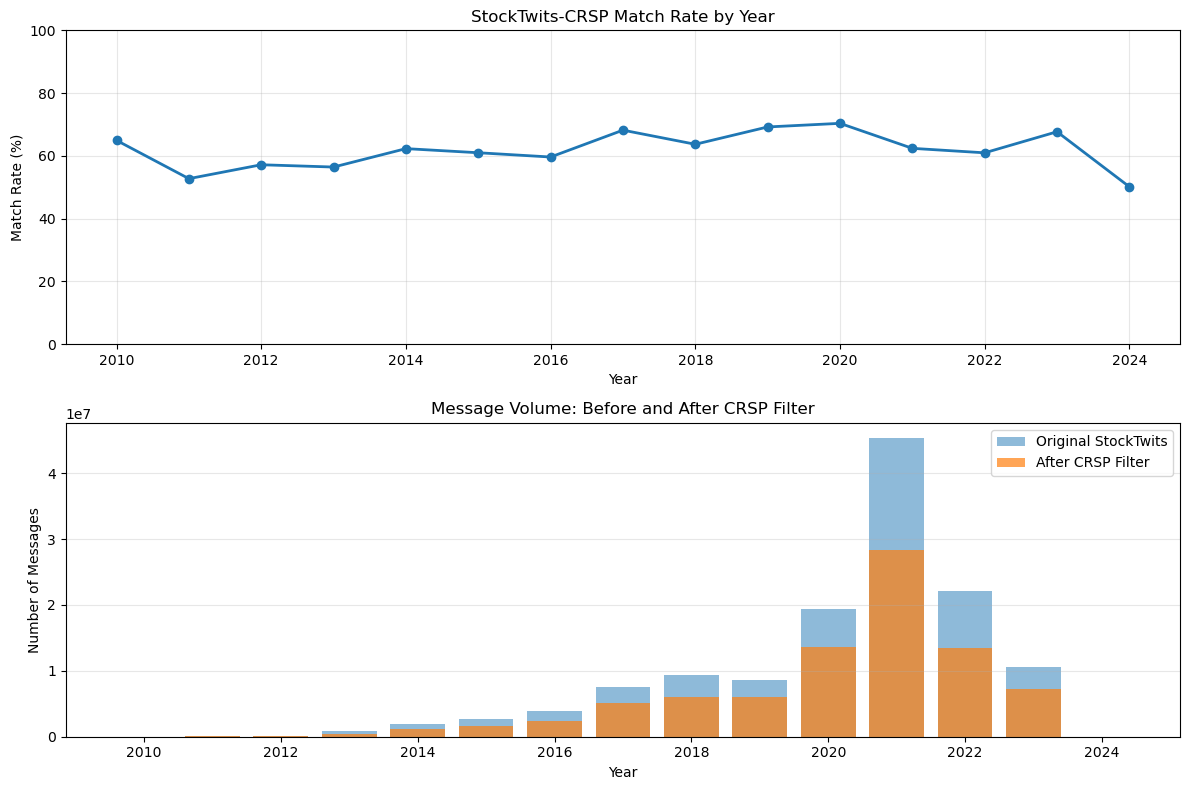


Match rate statistics:
  Mean: 61.80%
  Median: 62.31%
  Min: 50.16% (year 2024)
  Max: 70.37% (year 2020)


In [12]:
# Visualize match rates by year
import matplotlib.pyplot as plt

if len(df_stats) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Plot 1: Match rate by year
    axes[0].plot(df_stats['year'], df_stats['match_rate'], marker='o', linewidth=2)
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Match Rate (%)')
    axes[0].set_title('StockTwits-CRSP Match Rate by Year')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim([0, 100])
    
    # Plot 2: Volume by year
    axes[1].bar(df_stats['year'], df_stats['stocktwits_rows'], alpha=0.5, label='Original StockTwits')
    axes[1].bar(df_stats['year'], df_stats['merged_rows'], alpha=0.7, label='After CRSP Filter')
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Number of Messages')
    axes[1].set_title('Message Volume: Before and After CRSP Filter')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nMatch rate statistics:")
    print(f"  Mean: {df_stats['match_rate'].mean():.2f}%")
    print(f"  Median: {df_stats['match_rate'].median():.2f}%")
    print(f"  Min: {df_stats['match_rate'].min():.2f}% (year {df_stats.loc[df_stats['match_rate'].idxmin(), 'year']:.0f})")
    print(f"  Max: {df_stats['match_rate'].max():.2f}% (year {df_stats.loc[df_stats['match_rate'].idxmax(), 'year']:.0f})")

## 9. Identify Unmatched Symbols

In [13]:
# Load one year to analyze which symbols didn't match
if overlap_years:
    analysis_year = overlap_years[-1]  # Use most recent year
    
    st_file = EXPLODED_FOLDER / f"stocktwits_exploded_{analysis_year}.csv"
    crsp_file = CRSP_FOLDER / f"dsf_final_{analysis_year}.pkl"
    merged_file = OUTPUT_FOLDER / f"stocktwits_crsp_{analysis_year}.csv"
    
    df_st_analysis = pd.read_csv(st_file)
    df_crsp_analysis = pd.read_pickle(crsp_file)
    df_merged_analysis = pd.read_csv(merged_file)
    
    # Find symbols in StockTwits but not matched with CRSP
    st_symbols = set(df_st_analysis['symbol'].str.upper())
    crsp_tickers = set(df_crsp_analysis['ticker'].str.upper())
    matched_symbols = set(df_merged_analysis['symbol'].str.upper())
    unmatched_symbols = st_symbols - matched_symbols
    
    print(f"\nAnalyzing unmatched symbols for year {analysis_year}:")
    print(f"{'='*60}")
    print(f"Total symbols in StockTwits: {len(st_symbols):,}")
    print(f"Total tickers in CRSP: {len(crsp_tickers):,}")
    print(f"Matched symbols: {len(matched_symbols):,}")
    print(f"Unmatched symbols: {len(unmatched_symbols):,}\n")
    
    # Count messages for unmatched symbols
    unmatched_df = df_st_analysis[df_st_analysis['symbol'].str.upper().isin(unmatched_symbols)]
    unmatched_volume = unmatched_df['symbol'].value_counts().head(20)
    
    print(f"Top 20 unmatched symbols by message volume:")
    print(unmatched_volume)
    
    # Check if they're in CRSP but different dates
    print(f"\nChecking if unmatched symbols exist in CRSP (different dates):")
    top_unmatched = unmatched_volume.head(5).index.tolist()
    for sym in top_unmatched:
        in_crsp = sym in crsp_tickers
        print(f"  {sym}: {'YES (in CRSP)' if in_crsp else 'NO (not in CRSP)'}")



Analyzing unmatched symbols for year 2024:
Total symbols in StockTwits: 1,825
Total tickers in CRSP: 5,358
Matched symbols: 1,043
Unmatched symbols: 782

Top 20 unmatched symbols by message volume:
symbol
BTC.X      982
BETSF      706
SPY        544
ICP.X      283
DOGE.X     222
TRB.X      217
QQQ        155
BAD.X      142
SOL.X      131
NIO        117
MUSE.X     106
SHIB.X      88
MEDIA.X     88
SEI.X       80
LCX.X       78
ETH.X       74
XRP.X       73
POLC        70
BONK.X      58
BABA        57
Name: count, dtype: int64

Checking if unmatched symbols exist in CRSP (different dates):
  BTC.X: NO (not in CRSP)
  BETSF: NO (not in CRSP)
  SPY: NO (not in CRSP)
  ICP.X: NO (not in CRSP)
  DOGE.X: NO (not in CRSP)


## 10. Final Data Schema

The merged data includes:

### From StockTwits (cleaned & exploded):
- `message_id`: Unique message identifier
- `user_id`: User identifier
- `symbol`: Stock ticker symbol (one row per symbol)
- `date`: Trading date (first market close after message)
- `created_at`: Original timestamp (US/Eastern)
- `sentiment`: Bullish/Bearish label
- `time`: Time of day
- `hour`: Hour of day (0-23)
- `is_after_hours`: After market close indicator
- `session`: Market session category

### From CRSP - Market Data:
- `permno`: CRSP permanent number (stock identifier)
- `prc`: Closing price
- `vol`: Trading volume
- `shrout`: Shares outstanding
- `ret`: Daily return

### From CRSP - Abnormal Returns (Target Variables):
Multiple models and horizons for machine learning prediction:

**Models:**
- `ar_dgtw_{h}`: DGTW (Daniel, Grinblatt, Titman, Wermers) abnormal return
- `ar_capm_{h}`: CAPM abnormal return
- `ar_FF3_{h}`: Fama-French 3-factor abnormal return
- `ar_FF5_{h}`: Fama-French 5-factor abnormal return
- `ar_FF6_{h}`: Fama-French 6-factor abnormal return

**Horizons (h):** 1, 3, 5, 10, 21, 42, 63, 252 trading days
- Standardized horizons from feature_proposal.md: 5, 21, 63, 252 days (~1 week, 1 month, 1 quarter, 1 year)
- Additional horizons for granularity: 1, 3, 10, 42 days

### Key Notes:
- **Inner join**: Only stocks that appear in CRSP (US-listed) are retained
- **Date matching**: Ensures message date aligns with CRSP trading date
- **Target variables ready**: Abnormal returns serve as dependent variables for ML models
- **Feature extraction ready**: Data is filtered and ready for calculating social media features from feature_proposal.md